# ROBNA ZATEMNITEV SONCA


## Potrebni Python moduli

In [1]:
%matplotlib inline
from astropy.io import fits # modul za delo s fits posnetki
import matplotlib.pyplot as plt # modul za risanje grafov
import numpy as np # modul za numerične operacije
from scipy.optimize import curve_fit
from scipy.optimize import least_squares
from scipy.ndimage import gaussian_filter1d # modul za glajenje podatkov z Gaussovo funkcijo
import os
from matplotlib import colormaps

In [2]:
# preberemo podatke o tej sliki iz fits datoteke
image_data = fits.getdata(os.path.join(os.path.abspath(''), "S2_0000_list_100r_48T_32reg.fit"))

## Prikaz posnete slike

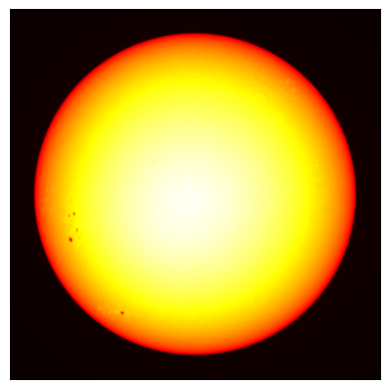

In [3]:
# prikazemo podatke kot sliko v črno-rumenem-rdečem filtru, v katerem se boljše vidi opazovani pojav
plt.imshow(image_data, cmap = 'hot');
plt.xlabel('px');
plt.ylabel('px');
plt.gca().get_xaxis().set_visible(False)
plt.gca().get_yaxis().set_visible(False)

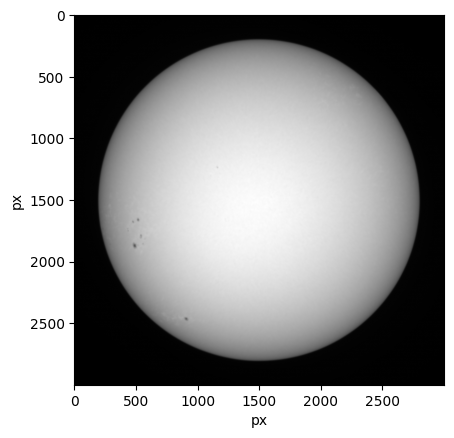

In [4]:
# prikazemo podatke kot sliko v sivem filtru
plt.imshow(image_data, cmap = 'gray');
plt.xlabel('px');
plt.ylabel('px');

## Izračun centra Sonca na sliki

In [5]:
# threshold nam definira locnico med signalom (tam kjer je Sonce na sliki) in delom slike brez signala
# Slika je umerjena tako, da ima sredisce ploskvice svetlost okoli 1. Spodnji racun deluje za poljubno umerjeno sliko
threshold = 0.2 * np.percentile(image_data,95)

# naredimo masko, to je slika, ki ima vrednost slike tam kjer je signal nad thresholdom in 0 tam kjer ni
mask = image_data > threshold

# naredimo seznam pikslov, ki so nad thresholdom loceno po y in x osi slike
ys, xs = np.nonzero(mask)

# center ploskvice Sonca je definiran s teziscem
# izracunamo tezisce kot povprecje pozicij pikslov nad thresholdom po vsaki osi
cy = ys.mean()
cx = xs.mean()

print('center:', cx, cy)

center: 1499.4272819085775 1500.7332428267837


## Risanje kocentričnih krogov

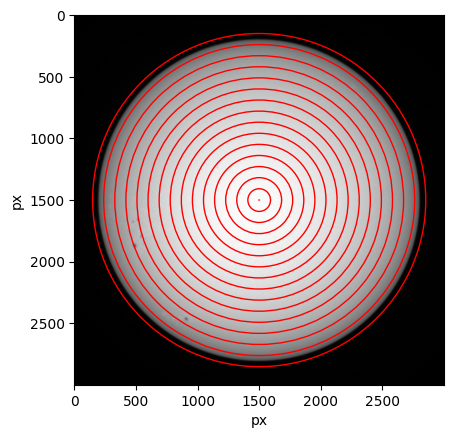

In [6]:
# prikazemo sliko in narisemo kroge okoli centra, ki predstavljajo razdalje od centra
plt.imshow(image_data, cmap = 'gray');

for radius in np.arange(2, 1400, 90):
    circle = plt.Circle((cx, cy), radius, color = 'r', fill = False)
    plt.gca().add_patch(circle)

plt.xlabel('px');
plt.ylabel('px');

## Povprečna svetlost posameznega kolobarja

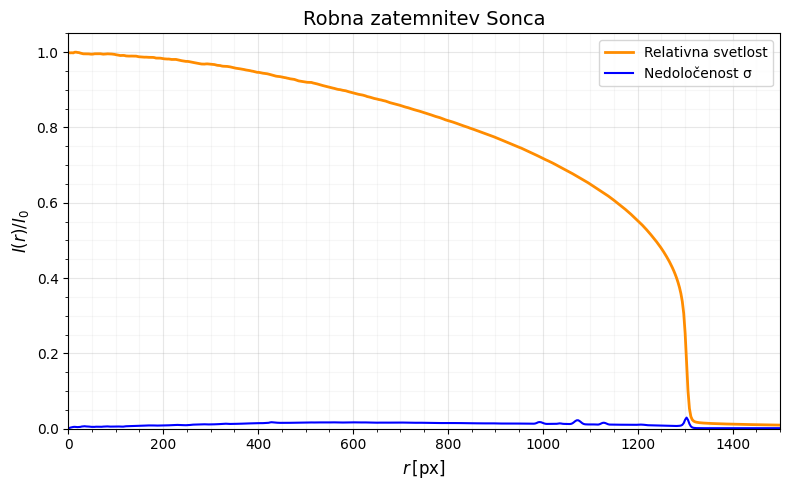

In [7]:
# IZRAČUN RADIALNEGA PROFILA SVETLOSTI

# Koordinatna mreža slike
y, x = np.indices(image_data.shape)

# Oddaljenost vsakega piksla od središča s Pitagorovim izrekom
r = np.sqrt((x - cx)**2 + (y - cy)**2)

# Parametri radialnih kolobarjev
n_bins = 500          # število kolobarjev
r_max = 1500.0        # maksimalni analizirani radij [px]
dr = r_max / n_bins   # debelina posameznega kolobarja

# Seznami za rezultate
radij = []
svetlost = []
nedolocenost = []


# ZANKA PO KOLOBARJIH

# Zanka, ki gre skozi vsak kolobar od 0 do r_max z debelino dr
for r_ in np.linspace(0, r_max, n_bins):

    # Maska za izbiro pikslov v trenutnem kolobarju
    mask = (r > r_) & (r < r_ + dr)
    # Svetlost kolobarja (mediana) in dodatek za nedolocenost, da se izognemo deljenju z 0
    brightness = np.median(image_data[mask])

    # Standardni odklon svetlosti v kolobarju kot merilo nedolocenosti, dodatek za izogib deljenju z 0
    brightness_std = np.std(image_data[mask]) + 1e-90

    # Shranjevanje rezultatov
    radij.append(r_ + dr/2.)
    svetlost.append(brightness)
    nedolocenost.append(brightness_std)

# Pretvorba v numpy array
radij = np.array(radij)
svetlost = np.array(svetlost)
nedolocenost = np.array(nedolocenost)


# NORMALIZACIJA

# Normalizacija glede na maksimalno svetlost
I0 = np.max(svetlost)

svetlost = svetlost / I0
nedolocenost = nedolocenost / I0


# RISANJE GRAFA

plt.figure(figsize=(8,5))

# Glavna krivulja
plt.plot(radij, svetlost, color='darkorange', lw=2, label='Relativna svetlost')

# Senčeno območje nedoločenosti
# plt.fill_between(radij, svetlost - nedolocenost, svetlost + nedolocenost, color='orange', alpha=0.3, label='1σ nedoločenost')

plt.plot(radij, nedolocenost, color='b', label='Nedoločenost σ')

# Oznake osi
plt.xlabel(r'$r\,[\mathrm{px}]$', fontsize=12)
plt.ylabel(r'$I(r)/I_0$', fontsize=12)

# Naslov
plt.title('Robna zatemnitev Sonca', fontsize=14)

# Mreža
plt.grid(which='major', alpha=0.3)
plt.grid(which='minor', alpha=0.1)
plt.minorticks_on()

# Omejitve osi
plt.xlim(0, 1500)
plt.ylim(0, 1.05)

# Legenda
plt.legend()

# Lepši razpored elementov
plt.tight_layout()

# Prikaz grafa
plt.show()

## Modeliranje meritev



### 1. model: Tanka atmosfera, ki absorbira svetlobo, a je ne seva

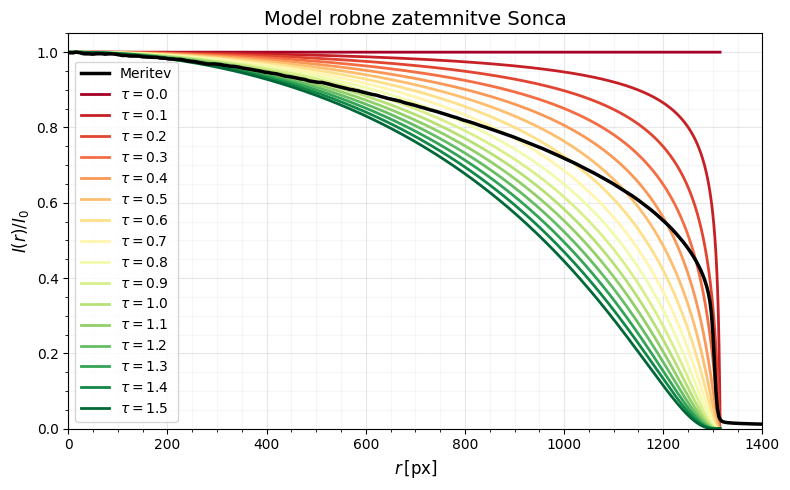

In [ ]:
# RISANJE MERITEV

plt.figure(figsize=(8,5))

# Meritve
plt.plot(radij, svetlost, color='black', lw=2.5, label='Meritev', zorder = 4)


# MODEL ROBNE ZATEMNITVE

# Radialna mreža za model
r_model = np.linspace(0, 1400, 2000)

# Ocenjeni radij Sonca [px]
R = 1315.0


def model_absorbcije_tanka_atmosfera(tau):
    # Izognemo se sqrt negativnih števil zunaj Sonca z masko, ki določa območje znotraj radija R
    inside = r_model < R

    # Inicializacija modela tako, da je povsod NaN (neveljavno), kar nam bo pomagalo pri risanju samo znotraj Sonca
    I_model = np.full_like(r_model, np.nan)

    # Model tanke absorpcijske atmosfere - izračunamo kot eksponentni padec svetlosti glede na optično debelino in geometrijsko faktor mu, ki upošteva kot gledanja
    mu = np.sqrt(1 - (r_model[inside] / R)**2)

    I_model[inside] = np.exp(-tau * (1/mu - 1))

    # Normalizacija modela glede na svetlost v središču, da se ujema z meritvami
    return I_model / I_model[0]



# Različne vrednosti optične debeline
tau_values = [0.0, 0.5, 0.69, 0.8, 1.2]
tau_values = np.linspace(0,1.5, 16)
# Barve modelov
colors = ['royalblue', 'seagreen', 'darkorange', 'crimson', 'purple']
colors = colormaps.get_cmap('RdYlGn')(tau_values/1.5)
for tau, color in zip(tau_values, colors):
    I_model = model_absorbcije_tanka_atmosfera(tau)
    # Risanje modela
    plt.plot(r_model, I_model, lw=2, color=color, label=fr'$\tau = {tau:.1f}$')



# OBLIKOVANJE GRAFA

plt.xlabel(r'$r\,[\mathrm{px}]$', fontsize=12)
plt.ylabel(r'$I(r)/I_0$', fontsize=12)

plt.title('Model robne zatemnitve Sonca', fontsize=14)

plt.xlim(0, 1400)
plt.ylim(0, 1.05)

# Mreža
plt.grid(which='major', alpha=0.3)
plt.grid(which='minor', alpha=0.1)
plt.minorticks_on()

# Legenda
plt.legend()

# Lepši razpored
plt.tight_layout()

# Prikaz
plt.show() 

### Izračun najboljše vrednosti 1. modela

Najboljši τ = 0.464 ± 0.142


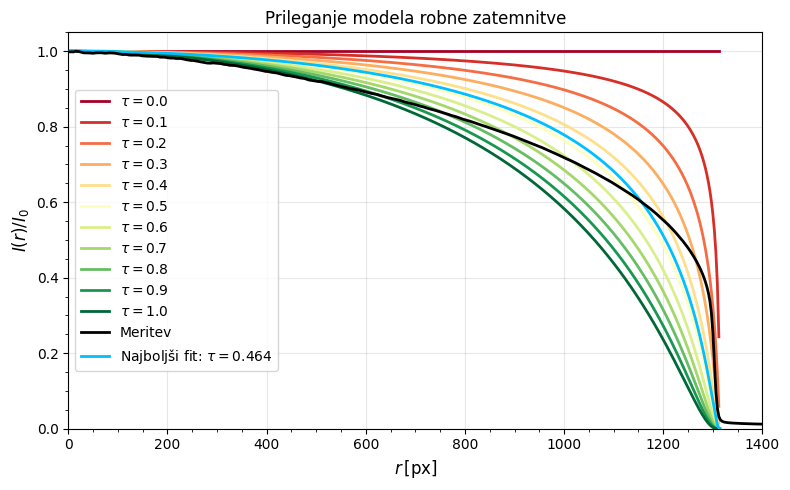

In [10]:
# MODEL ROBNE ZATEMNITVE

R = 1315.0

# Funkcija, ki definira model robne zatemnitve glede na radij r in optično debelino tau
def limb_darkening_model(r, tau):

    # zaščita pred sqrt negativnih števil
    mu = np.sqrt(np.clip(1 - (r / R)**2, 1e-10, None))

    # model tanke absorpcijske atmosfere - izračunamo kot eksponentni padec svetlosti glede na optično debelino in geometrijsko faktor mu, ki upošteva kot gledanja
    I = np.exp(-tau * (1/mu - 1))

    # normalizacija
    return I / I[0]


# FITANJE MODELA

# uporabimo samo podatke znotraj Sonca
mask = radij < R

# podatki za fitanje
r_fit = radij[mask]
I_fit = svetlost[mask]


# začetni približek za tau
tau0 = 0.5

# optimizacija parametra tau tako, da minimizira razliko med modelom in meritvami
def residuals(params):
    tau = params[0]
    return limb_darkening_model(r_fit, tau) - I_fit

rezultat = least_squares(residuals, x0=[tau0], bounds=(0, 5), method='dogbox')

# najboljša vrednost tau
tau_best = rezultat.x[0]

# približna negotovost parametra
J = rezultat.jac
cov = np.linalg.inv(J.T @ J)
tau_err = np.sqrt(np.diag(cov))[0]

print(f"Najboljši τ = {tau_best:.3f} ± {tau_err:.3f}")


# RISANJE

plt.figure(figsize=(8,5))


tau_values = np.linspace(0,1, 11)

# Barve modelov
colors = colormaps.get_cmap('RdYlGn')(tau_values)

for tau, color in zip(tau_values, colors):
    I_model = limb_darkening_model(r_fit, tau)

    # Risanje modela
    plt.plot(r_fit, I_model, lw=2, color=color, label=fr'$\tau = {tau:.1f}$')

# meritve
plt.plot(radij, svetlost, color='black', lw=2, label='Meritev', zorder = 4.1)

# najboljši model
r_model = np.linspace(0, R, 2000)

plt.plot(r_model, limb_darkening_model(r_model, tau_best), color='deepskyblue', lw=2, label=fr'Najboljši fit: $\tau={tau_best:.3f}$', zorder=4)

# izgled
plt.xlabel(r'$r\,[\mathrm{px}]$', fontsize=12)
plt.ylabel(r'$I(r)/I_0$', fontsize=12)

plt.title('Prileganje modela robne zatemnitve')

plt.xlim(0, 1400)
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.minorticks_on()

plt.legend(loc='center left')

plt.tight_layout()
plt.show()

### 2. model: Tanka atmosfera, ki absorbira svetlobo s površja in seva še svoj delež svetlobe

Najboljši τ = 1.030 ± 0.734
Najboljši T_a/T_b = 1.570 ± 0.184


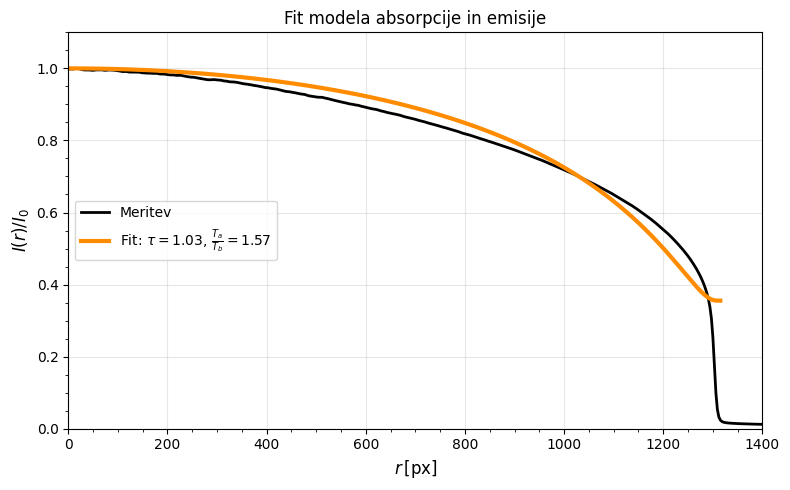

In [12]:
# PARAMETRI

R = 1315.0


# MODEL ABSORPCIJE + EMISIJE

# Funkcija, ki definira model robne zatemnitve glede na radij r, optično debelino tau in temperaturni faktor t_ratio, ki predstavlja razmerje med temperaturo emisijske plasti in osnovno temperaturo
def model_emisija(r, tau, t_ratio):

    # zaščita pred sqrt negativnih števil
    mu = np.sqrt(np.clip(1 - (r / R)**2, 1e-10, None))

    # Stefan-Boltzmannov zakon pravi, da je svetlost sorazmerna s četrto potenco temperature, zato izračunamo razmerje svetlosti kot četrto potenco temperaturnega faktorja
    i_ratio = t_ratio**4

    # model absorpcije + emisije, kjer absorpcija zmanjša svetlost glede na optično debelino, emisija pa poveča svetlost glede na temperaturni faktor
    I = ((i_ratio - 1) * np.exp(-tau / mu) + 1) / ((i_ratio - 1) * np.exp(-tau) + 1)
    return I


# PODATKI ZA FIT

# uporabimo samo podatke znotraj Sonca
mask = radij < R

r_fit = radij[mask]
I_fit = svetlost[mask]


# ZAČETNI PRIBLIŽKI

tau0 = 0.5
t_ratio0 = 1.2

p0 = [tau0, t_ratio0]


# FITANJE

def residuals(params):
    tau, t_ratio = params
    return model_emisija(r_fit, tau, t_ratio) - I_fit

rezultat = least_squares(residuals, x0=p0, bounds=([0, 1.0], [5, 3.0]), method='dogbox')

# najboljši parametri
tau_best, t_ratio_best = rezultat.x

# približna negotovost iz Jacobiana
J = rezultat.jac
cov = np.linalg.inv(J.T @ J)
tau_err, t_ratio_err = np.sqrt(np.diag(cov))

print(f"Najboljši τ = {tau_best:.3f} ± {tau_err:.3f}")
print(f"Najboljši T_a/T_b = {t_ratio_best:.3f} ± {t_ratio_err:.3f}")


# RISANJE

plt.figure(figsize=(8,5))

# meritve
plt.plot(radij, svetlost, color='black', lw=2, label='Meritev')

# najboljši model
r_model = np.linspace(0, R, 2000)

plt.plot(r_model, model_emisija(r_model, tau_best, t_ratio_best), color='darkorange', lw=3, label=(fr'Fit: $\tau={tau_best:.2f}$, 'fr'$\frac{{T_a}}{{T_b}}={t_ratio_best:.2f}$'))

# OBLIKOVANJE GRAFA

plt.xlabel(r'$r\,[\mathrm{px}]$', fontsize=12)
plt.ylabel(r'$I(r)/I_0$', fontsize=12)

plt.title('Fit modela absorpcije in emisije')

plt.xlim(0, 1400)
plt.ylim(0, 1.1)

plt.grid(alpha=0.3)
plt.minorticks_on()

plt.legend(loc='center left')

plt.tight_layout()
plt.show()

### 3. model: Atmosfera s temperaturnim profilom

a0 = 0.1588 ± 0.3785
a1 = 0.9564 ± 1.2148
a2 = -0.0672 ± 0.4531


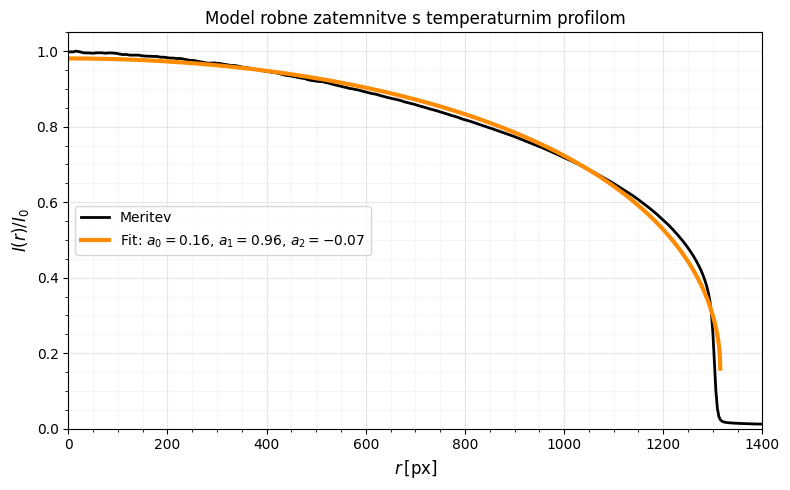

In [13]:
# PARAMETRI

R = 1315.0


# MODEL ROBNE ZATEMNITVE

# Funkcija, ki definira model robne zatemnitve glede na radij r in koeficiente a0, a1, a2, ki predstavljajo linearni temperaturni profil znotraj Sonca
def model_temperaturni_profil(r, a0, a1, a2):

    # zaščita pred negativnimi vrednostmi
    mu2 = np.clip(1 - (r / R)**2, 0, None)

    # model (z uporabo Boltzmannovega zakona in linearnega temperaturnega profila)
    I = (a0 + a1 * np.sqrt(mu2) + 2 * a2 * mu2)
    return I


# PODATKI ZA FIT

# uporabimo samo točke znotraj Sonca
mask = radij < R

r_fit = radij[mask]
I_fit = svetlost[mask]


# ZAČETNI PRIBLIŽKI

p0 = [0.3, 0.8, 0.0]


# FITANJE

def residuals(params):
    a0, a1, a2 = params
    return model_temperaturni_profil(r_fit, a0, a1, a2) - I_fit

rezultat = least_squares(residuals, x0=p0, bounds=(-np.inf, np.inf), method='dogbox')

# najboljši parametri
a0_best, a1_best, a2_best = rezultat.x

# negotovosti parametrov
J = rezultat.jac
cov = np.linalg.inv(J.T @ J)
a0_err, a1_err, a2_err = np.sqrt(np.diag(cov))

# izpis rezultatov
print(f"a0 = {a0_best:.4f} ± {a0_err:.4f}")
print(f"a1 = {a1_best:.4f} ± {a1_err:.4f}")
print(f"a2 = {a2_best:.4f} ± {a2_err:.4f}")


# RISANJE

plt.figure(figsize=(8,5))

# meritve
plt.plot(radij, svetlost, color='black', lw=2, label='Meritev')

# najboljši model
r_model = np.linspace(0, R, 2000)

plt.plot(r_model, model_temperaturni_profil(r_model, a0_best, a1_best, a2_best), color='darkorange', lw=3, label=(fr'Fit: $a_0={a0_best:.2f}$, 'fr'$a_1={a1_best:.2f}$, 'fr'$a_2={a2_best:.2f}$'))


# OBLIKOVANJE GRAFA

plt.xlabel(r'$r\,[\mathrm{px}]$', fontsize=12)
plt.ylabel(r'$I(r)/I_0$', fontsize=12)

plt.title('Model robne zatemnitve s temperaturnim profilom')

plt.xlim(0, 1400)
plt.ylim(0, 1.05)

plt.grid(which='major', alpha=0.3)
plt.grid(which='minor', alpha=0.1)
plt.minorticks_on()

plt.legend(loc='center left')

plt.tight_layout()

plt.show()

### 3. model z več parametri

a0 = -0.0566 ± 0.6760
a1 = 2.4104 ± 3.9714
a2 = -1.4042 ± 3.5062
a3 = 0.4843 ± 1.2595


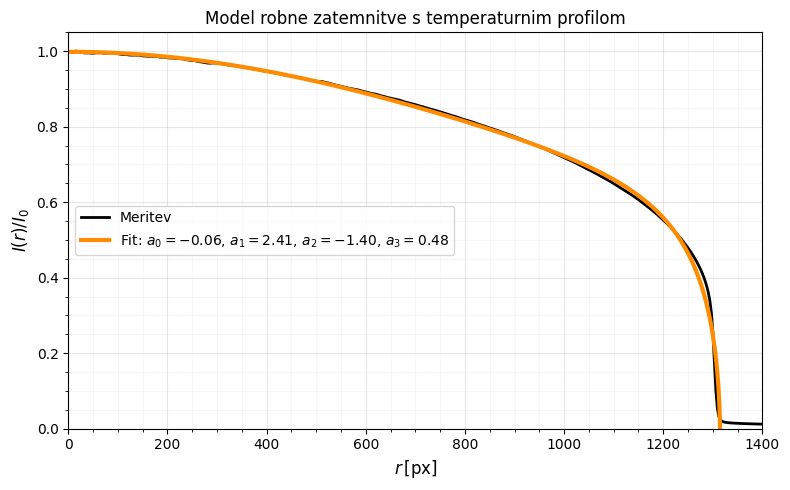

In [14]:
# MODEL ROBNE ZATEMNITVE

# Funkcija, ki definira model robne zatemnitve glede na radij r in koeficiente a0, a1, a2, a3,
# ki predstavljajo temperaturni profil znotraj Sonca
def model_temperaturni_profil(r, a0, a1, a2, a3):

    # zaščita pred negativnimi vrednostmi
    mu2 = np.clip(1 - (r / R)**2, 0, None)

    # model
    I = (a0 + a1 * np.sqrt(mu2) + 2 * a2 * mu2 + 3 * a3 * mu2**(3/2))
    return I


# PODATKI ZA FIT

# uporabimo samo točke znotraj Sonca
mask = radij < R

r_fit = radij[mask]
I_fit = svetlost[mask]


# ZAČETNI PRIBLIŽKI

p0 = [0.3, 0.8, 0.0, 0.0]


# FITANJE

def residuals(params):
    a0, a1, a2, a3 = params
    return model_temperaturni_profil(r_fit, a0, a1, a2, a3) - I_fit

rezultat = least_squares(residuals, x0=p0, bounds=(-np.inf, np.inf), method='dogbox')

# najboljši parametri
a0_best, a1_best, a2_best, a3_best = rezultat.x

# negotovosti parametrov
J = rezultat.jac
cov = np.linalg.inv(J.T @ J)
a0_err, a1_err, a2_err, a3_err = np.sqrt(np.diag(cov))

# izpis rezultatov
print(f"a0 = {a0_best:.4f} ± {a0_err:.4f}")
print(f"a1 = {a1_best:.4f} ± {a1_err:.4f}")
print(f"a2 = {a2_best:.4f} ± {a2_err:.4f}")
print(f"a3 = {a3_best:.4f} ± {a3_err:.4f}")


# RISANJE

plt.figure(figsize=(8,5))

# meritve
plt.plot(radij, svetlost, color='black', lw=2, label='Meritev')

# najboljši model
r_model = np.linspace(0, R, 2000)

plt.plot(r_model, model_temperaturni_profil(r_model, a0_best, a1_best, a2_best, a3_best), color='darkorange', lw=3, label=(fr'Fit: $a_0={a0_best:.2f}$, 'fr'$a_1={a1_best:.2f}$, 'fr'$a_2={a2_best:.2f}$, 'fr'$a_3={a3_best:.2f}$'))


# OBLIKOVANJE GRAFA

plt.xlabel(r'$r\,[\mathrm{px}]$', fontsize=12)
plt.ylabel(r'$I(r)/I_0$', fontsize=12)

plt.title('Model robne zatemnitve s temperaturnim profilom')

plt.xlim(0, 1400)
plt.ylim(0, 1.05)

plt.grid(which='major', alpha=0.3)
plt.grid(which='minor', alpha=0.1)
plt.minorticks_on()

plt.legend(loc='center left')

plt.tight_layout()

plt.show()

## Prilagajanje modela na meritve

R = 1300.1
a0 = 0.317
a1 = 0.548
a2 = 0.061


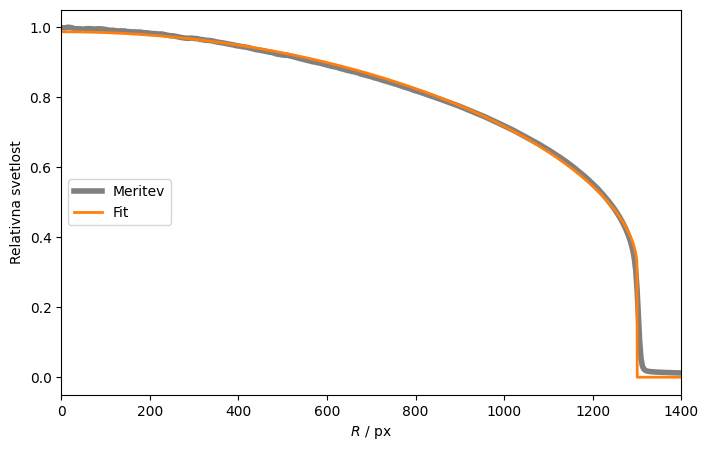

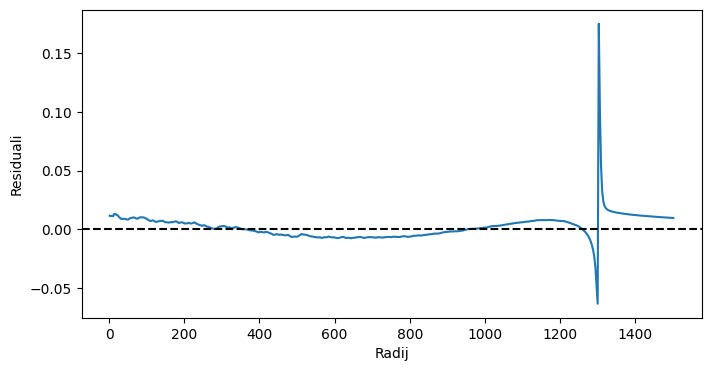

In [ ]:
# funkcija robne zatemnitve
def func_zatemnitev(r, R, a0, a1, a2):

    # prepreči negativne vrednosti pod korenom
    mu = np.clip(1 - (r/R)**2, 0, None)

    # model svetlosti 
    inside = a0 + a1*np.sqrt(mu) + 2.0*a2*mu

    # zunaj Sonca je svetlost 0
    return np.where(r >= R, 0.0, inside)


# začetni približki parametrov
R_init = 1310
a0_init = 0.30
a1_init = 0.60
a2_init = 0.05

init = [R_init, a0_init, a1_init, a2_init]


# omejitve parametrov
bounds = ([1200, 0.0, 0.0, -1.0],   # spodnje meje
          [1400, 1.0, 2.0, 1.0])    # zgornje meje


# FITANJE (DOGBOX)

def residuals(params):
    R, a0, a1, a2 = params
    model = func_zatemnitev(radij, R, a0, a1, a2)
    return model - svetlost

p0 = init

popt = least_squares(residuals, x0=p0, bounds=bounds, method='dogbox').x


# fitani parametri
R_fit, a0_fit, a1_fit, a2_fit = popt



# izpis rezultatov
print('R = %.1f' % (R_fit))
print('a0 = %.3f' % (a0_fit))
print('a1 = %.3f' % (a1_fit))
print('a2 = %.3f' % (a2_fit))


# GRAF MERITEV IN FITA

plt.figure(figsize=(8,5))

# meritve
plt.plot(radij, svetlost, '-', c='gray', lw=4, label='Meritev')

# gladka krivulja fita
rr = np.linspace(0, 1400, 2000)

plt.plot(rr, func_zatemnitev(rr, R_fit, a0_fit, a1_fit, a2_fit), c='C1', lw=2, label='Fit')

plt.xlabel('$R\\ /\\ \\mathrm{px}$')
plt.ylabel('Relativna svetlost')

plt.xlim(0, 1400)

plt.legend(loc='center left')

plt.show()


# RESIDUALI

fit = func_zatemnitev(radij, R_fit, a0_fit, a1_fit, a2_fit)

residuals = svetlost - fit

plt.figure(figsize=(8,4))

plt.plot(radij, residuals)

plt.axhline(0, color='black', ls='--')

plt.xlabel('Radij')
plt.ylabel('Residuali')

plt.show()

## Temperaturni profil Sončeve atmosfere

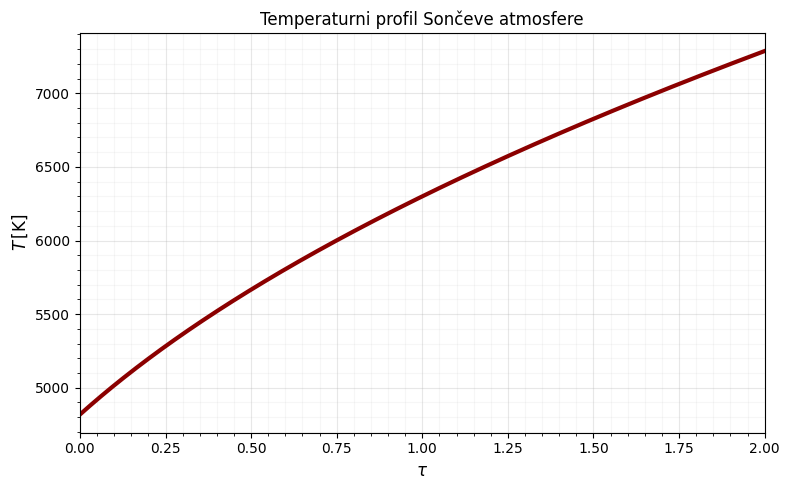

In [16]:
# OPTIČNA GLOBINA

tau = np.linspace(0, 2, 1000)


# SVETILNOSTNI PROFIL

# izračun svetlosti glede na fitane koeficiente in optično globino tau, kar nam daje svetlost kot funkcijo optične globine
S = (a0_fit + a1_fit * tau + a2_fit * tau**2)


# ZAŠČITA PRED NEGATIVNIMI VREDNOSTMI

# zaradi numeričnih napak lahko S postane rahlo negativen
S = np.clip(S, 1e-10, None)


# TEMPERATURNI PROFIL

# Stefan-Boltzmannov zakon:
T = S**0.25


# NORMALIZACIJA NA 6300 K PRI tau=1

S_tau1 = (a0_fit + a1_fit + a2_fit)

T_tau1 = S_tau1**0.25

# skaliranje temperature tako, da je pri tau=1 enaka 6300 K, kar je približna temperatura fotosfere Sonca
T = T * 6300 / T_tau1


# RISANJE

plt.figure(figsize=(8,5))

plt.plot(tau, T, color='darkred', lw=3)

# oznake osi
plt.xlabel(r'$\tau$', fontsize=12)
plt.ylabel(r'$T\,[\mathrm{K}]$', fontsize=12)

# naslov
plt.title('Temperaturni profil Sončeve atmosfere')

# meje osi
plt.xlim(0, 2)

# mreža
plt.grid(which='major', alpha=0.3)
plt.grid(which='minor', alpha=0.1)
plt.minorticks_on()

# lepši razpored elementov
plt.tight_layout()

# prikaz
plt.show()

## Dodatek

Če je fotosfera Sonca debela 100 km, do kam dobro drži aproksimacija $\tau(\theta)=\tau(\theta=0)/\cos \theta$?

Aproksimacija začne odstopati za več kot 1 % pri:
theta ≈ 85.2°


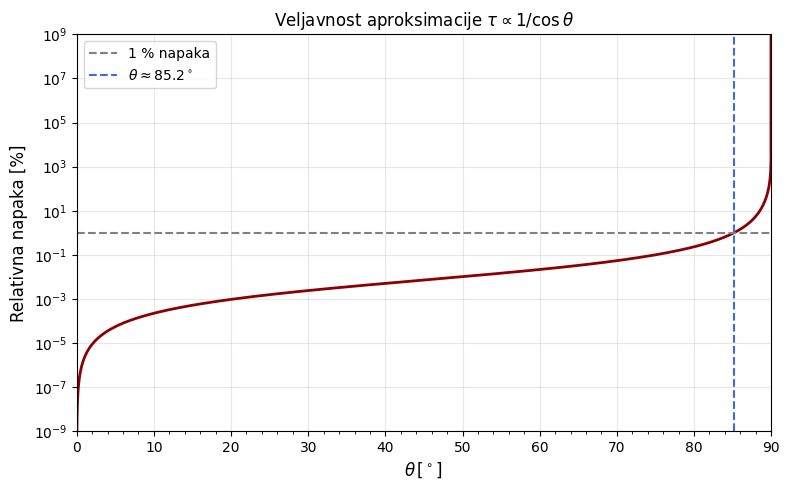

In [17]:
# PARAMETRI

R = 696000.0   # radij Sonca [km]
h = 100.0      # debelina fotosfere [km]

# koti
theta = np.linspace(-0.1, 1, 100)
theta = np.append(theta,  np.linspace(1, 89, 2000))
theta = np.append(theta,  np.linspace(89, 90.1, 100))

# v radianih
th = np.radians(theta)


# RAVNA APROKSIMACIJA

L_flat = h / np.cos(th)


# SFERIČNA GEOMETRIJA

# zaradi sferične geometrije je pot svetlobe skozi fotosfero daljša, kar vpliva na optično debelino in posledično na svetlost
L_sph = (np.sqrt((R + h)**2 - (R*np.sin(th))**2) - R*np.cos(th))


# RELATIVNA NAPAKA

rel_error = np.abs(L_sph - L_flat) / L_sph


# KJE NAPAKA PRESEŽE 1%?

mask = rel_error > 0.01

theta_limit = theta[mask][0]

print(f"Aproksimacija začne odstopati za več kot 1 % pri:")
print(f"theta ≈ {theta_limit:.1f}°")


# GRAF

plt.figure(figsize=(8,5))

plt.plot(theta, rel_error * 100, color='darkred', lw=2)

plt.axhline(1, color='gray', ls='--', label='1 % napaka')

plt.axvline(theta_limit, color='royalblue', ls='--', label=fr'$\theta \approx {theta_limit:.1f}^\circ$')

plt.xlabel(r'$\theta\,[^\circ]$', fontsize=12)
plt.ylabel('Relativna napaka [%]', fontsize=12)

plt.title('Veljavnost aproksimacije $\\tau \\propto 1/\\cos\\theta$')

plt.xlim(0,90)
plt.ylim(1e-9,1e9)

plt.gca().set_yscale('log')


plt.grid(alpha=0.3)
plt.minorticks_on()

plt.legend()

plt.tight_layout()
plt.show()

Veljavnost aproksimacije smo preverili s primerjavo ravne in sferične geometrijske fotosfere. Ker je debelina fotosfere (∼100 km) mnogo manjša od radija Sonca, aproksimacija dobro velja za večino opazovanih kotov in začne očitneje odstopati šele blizu roba Sončeve ploskvice.

